# Cohort retention | Olist

**Question:** Of the customers who first bought in a calendar month, how many placed another delivered order in each later month?

In [ ]:
from pathlib import Path
import os
import re
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

folder = Path.cwd()
if not (folder / 'queries.sql').exists() and (folder / 'cohort_retention' / 'queries.sql').exists():
    folder = folder / 'cohort_retention'

sql_text = (folder / 'queries.sql').read_text(encoding='utf-8')
query_blocks = re.split(r'(?=^-- (?:Q[0-9]+|Addition [0-9]+):)', sql_text, flags=re.M)
sql_by_name = {}

running the same SELECTs on the local Olist data snapshot


## Q1 — Delivered purchase baseline

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [2]:
q1 = run_query('Q1')
print(q1.to_string(index=False, max_rows=28))


 delivered_orders  unique_customers      first_purchase       last_purchase
            96478             93358 2016-09-15 12:16:38 2018-08-29 15:00:37


## Q2 — First purchase cohorts

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [3]:
q2 = run_query('Q2')
print(q2.to_string(index=False, max_rows=28))


cohort_month  cohort_size
  2016-09-01            1
  2016-10-01          262
  2016-12-01            1
  2017-01-01          717
  2017-02-01         1628
  2017-03-01         2503
  2017-04-01         2256
  2017-05-01         3451
  2017-06-01         3037
  2017-07-01         3752
  2017-08-01         4057
  2017-09-01         4004
  2017-10-01         4328
  2017-11-01         7060
  2017-12-01         5338
  2018-01-01         6842
  2018-02-01         6288
  2018-03-01         6774
  2018-04-01         6582
  2018-05-01         6506
  2018-06-01         5878
  2018-07-01         5949
  2018-08-01         6144


## Q3 — Calendar-month activity

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [4]:
q3 = run_query('Q3')
print(q3.to_string(index=False, max_rows=28))


order_month  orders  active_customers
 2016-09-01       1                 1
 2016-10-01     265               262
 2016-12-01       1                 1
 2017-01-01     750               718
 2017-02-01    1653              1630
 2017-03-01    2546              2508
 2017-04-01    2303              2274
 2017-05-01    3546              3479
 2017-06-01    3135              3076
 2017-07-01    3872              3802
 2017-08-01    4193              4114
 2017-09-01    4150              4083
 2017-10-01    4478              4417
 2017-11-01    7289              7183
 2017-12-01    5513              5450
 2018-01-01    7069              6974
 2018-02-01    6555              6400
 2018-03-01    7003              6914
 2018-04-01    6798              6744
 2018-05-01    6749              6693
 2018-06-01    6099              6061
 2018-07-01    6159              6100
 2018-08-01    6351              6310


## Q4 — Months since acquisition

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [5]:
q4 = run_query('Q4')
print(q4.to_string(index=False, max_rows=28))


 period_number  orders  customers
             0   94579      93358
             1     433        421
             2     283        273
             3     202        192
             4     181        176
             5     149        140
             6     133        129
             7     103        102
             8      88         86
             9      63         60
            10      75         75
            11      59         57
            12      36         36
            13      27         26
            14      25         22
            15      18         18
            16       9          8
            17      10         10
            19       3          3
            20       2          2


## Q5 — Distinct customer count matrix

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [6]:
q5 = run_query('Q5')
print(q5.to_string(index=False, max_rows=28))


cohort_month   p0   p1   p2   p3   p4   p5   p6
  2016-09-01    1  0.0  0.0  0.0  0.0  0.0  0.0
  2016-10-01  262  0.0  0.0  0.0  0.0  0.0  1.0
  2016-12-01    1  1.0  0.0  0.0  0.0  0.0  0.0
  2017-01-01  717  2.0  2.0  1.0  3.0  1.0  3.0
  2017-02-01 1628  3.0  5.0  2.0  7.0  2.0  4.0
  2017-03-01 2503 11.0  9.0 10.0  9.0  4.0  4.0
  2017-04-01 2256 14.0  5.0  4.0  6.0  6.0  8.0
  2017-05-01 3451 16.0 16.0 10.0 10.0 11.0 14.0
  2017-06-01 3037 15.0 12.0 13.0  9.0 12.0 11.0
  2017-07-01 3752 20.0 13.0  9.0 11.0  8.0 12.0
  2017-08-01 4057 28.0 14.0 11.0 14.0 21.0 12.0
  2017-09-01 4004 28.0 22.0 11.0 18.0  9.0  9.0
  2017-10-01 4328 31.0 11.0  4.0 10.0  9.0  9.0
  2017-11-01 7060 40.0 26.0 12.0 12.0 13.0  8.0
  2017-12-01 5338 11.0 15.0 18.0 14.0 11.0  9.0
  2018-01-01 6842 23.0 25.0 20.0 20.0 11.0 12.0
  2018-02-01 6288 22.0 25.0 19.0 16.0 14.0 13.0
  2018-03-01 6774 27.0 20.0 20.0  8.0  8.0  NaN
  2018-04-01 6582 39.0 20.0 16.0  9.0  NaN  NaN
  2018-05-01 6506 34.0 17.0 12.0  NaN  N

## Q6 — Cohort denominators

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [7]:
q6 = run_query('Q6')
print(q6.to_string(index=False, max_rows=28))


cohort_month  cohort_size
  2016-09-01            1
  2016-10-01          262
  2016-12-01            1
  2017-01-01          717
  2017-02-01         1628
  2017-03-01         2503
  2017-04-01         2256
  2017-05-01         3451
  2017-06-01         3037
  2017-07-01         3752
  2017-08-01         4057
  2017-09-01         4004
  2017-10-01         4328
  2017-11-01         7060
  2017-12-01         5338
  2018-01-01         6842
  2018-02-01         6288
  2018-03-01         6774
  2018-04-01         6582
  2018-05-01         6506
  2018-06-01         5878
  2018-07-01         5949
  2018-08-01         6144


## Q7 — SQL-pivoted retention percentages

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [8]:
q7 = run_query('Q7')
print(q7.to_string(index=False, max_rows=28))


cohort_month  cohort_size    p0       p1     p2     p3     p4     p5     p6
  2016-09-01            1 100.0   0.0000 0.0000 0.0000 0.0000 0.0000 0.0000
  2016-10-01          262 100.0   0.0000 0.0000 0.0000 0.0000 0.0000 0.3817
  2016-12-01            1 100.0 100.0000 0.0000 0.0000 0.0000 0.0000 0.0000
  2017-01-01          717 100.0   0.2789 0.2789 0.1395 0.4184 0.1395 0.4184
  2017-02-01         1628 100.0   0.1843 0.3071 0.1229 0.4300 0.1229 0.2457
  2017-03-01         2503 100.0   0.4395 0.3596 0.3995 0.3596 0.1598 0.1598
  2017-04-01         2256 100.0   0.6206 0.2216 0.1773 0.2660 0.2660 0.3546
  2017-05-01         3451 100.0   0.4636 0.4636 0.2898 0.2898 0.3187 0.4057
  2017-06-01         3037 100.0   0.4939 0.3951 0.4281 0.2963 0.3951 0.3622
  2017-07-01         3752 100.0   0.5330 0.3465 0.2399 0.2932 0.2132 0.3198
  2017-08-01         4057 100.0   0.6902 0.3451 0.2711 0.3451 0.5176 0.2958
  2017-09-01         4004 100.0   0.6993 0.5495 0.2747 0.4496 0.2248 0.2248
  2017-10-01

## Q8 — Maturity-aware mean curve

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [9]:
q8 = run_query('Q8')
print(q8.to_string(index=False, max_rows=28))


 period_number  observed_cohorts  average_all_cohorts_pct  stable_cohorts  average_retention_pct  weighted_retention_pct
             0                23                 100.0000              20               100.0000                100.0000
             1                22                   4.9563              19                 0.4757                  0.4830
             2                21                   0.2889              18                 0.3370                  0.3370
             3                20                   0.2130              17                 0.2506                  0.2556
             4                19                   0.2428              16                 0.2883                  0.2565
             5                18                   0.1921              15                 0.2305                  0.2257
             6                17                   0.2377              14                 0.2613                  0.2316


## Q9 — Best and worst month-1 cohorts and a delivery check

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [10]:
q9 = run_query('Q9')
print(q9.to_string(index=False, max_rows=28))


cohort_month  cohort_size  returning_customers  month_1_pct  first_order_review  late_delivery_pct
  2017-10-01         4328                   31       0.7163               4.202               5.41
  2017-09-01         4004                   28       0.6993               4.264               5.19
  2017-08-01         4057                   28       0.6902               4.314               3.18
  2017-04-01         2256                   14       0.6206               4.131               7.93
  2018-04-01         6582                   39       0.5925               4.204               5.30
  2017-11-01         7060                   40       0.5666               3.983              14.38
  2017-07-01         3752                   20       0.5330               4.258               3.38
  2018-05-01         6506                   34       0.5226               4.229               8.30
  2018-07-01         5949                   31       0.5211               4.315               4.52
  2017-06-

## Q10 — Incremental and cumulative item revenue

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [11]:
q10 = run_query('Q10')
print(q10.to_string(index=False, max_rows=28))


cohort_month  period_number  cohort_size  revenue_brl  revenue_per_original_customer_brl  cumulative_revenue_per_customer_brl
  2016-09-01              0            1       134.97                           134.9700                             134.9700
  2016-09-01              1            1         0.00                             0.0000                             134.9700
  2016-09-01              2            1         0.00                             0.0000                             134.9700
  2016-09-01              3            1         0.00                             0.0000                             134.9700
  2016-09-01              4            1         0.00                             0.0000                             134.9700
  2016-09-01              5            1         0.00                             0.0000                             134.9700
  2016-09-01              6            1         0.00                             0.0000                             1

## Addition 1 — Review score by delivery timeliness

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [12]:
addition_1 = run_query('Addition 1')
print(addition_1.to_string(index=False, max_rows=28))


delivery_group  reviewed_orders  average_review  low_review_pct
          late             7661           2.567           53.99
       on time            88163           4.294            9.19


## Addition 2 — Primary payment method on delivered orders

The complete statement is read from `queries.sql`; the data below comes from executing it, not from recalculating cohorts in pandas.

In [13]:
addition_2 = run_query('Addition 2')
print(addition_2.to_string(index=False, max_rows=28))


payment_type  delivered_orders  order_share_pct
 credit_card             72825            75.48
      boleto             19191            19.89
     voucher              2977             3.09
  debit_card              1484             1.54


## Visual 1 — retention heatmap

A separate neutral strip shows the 100% baseline. The coloured cells use a sub-1% scale so meaningful differences among returning customers remain visible. An unobserved future month is blank.

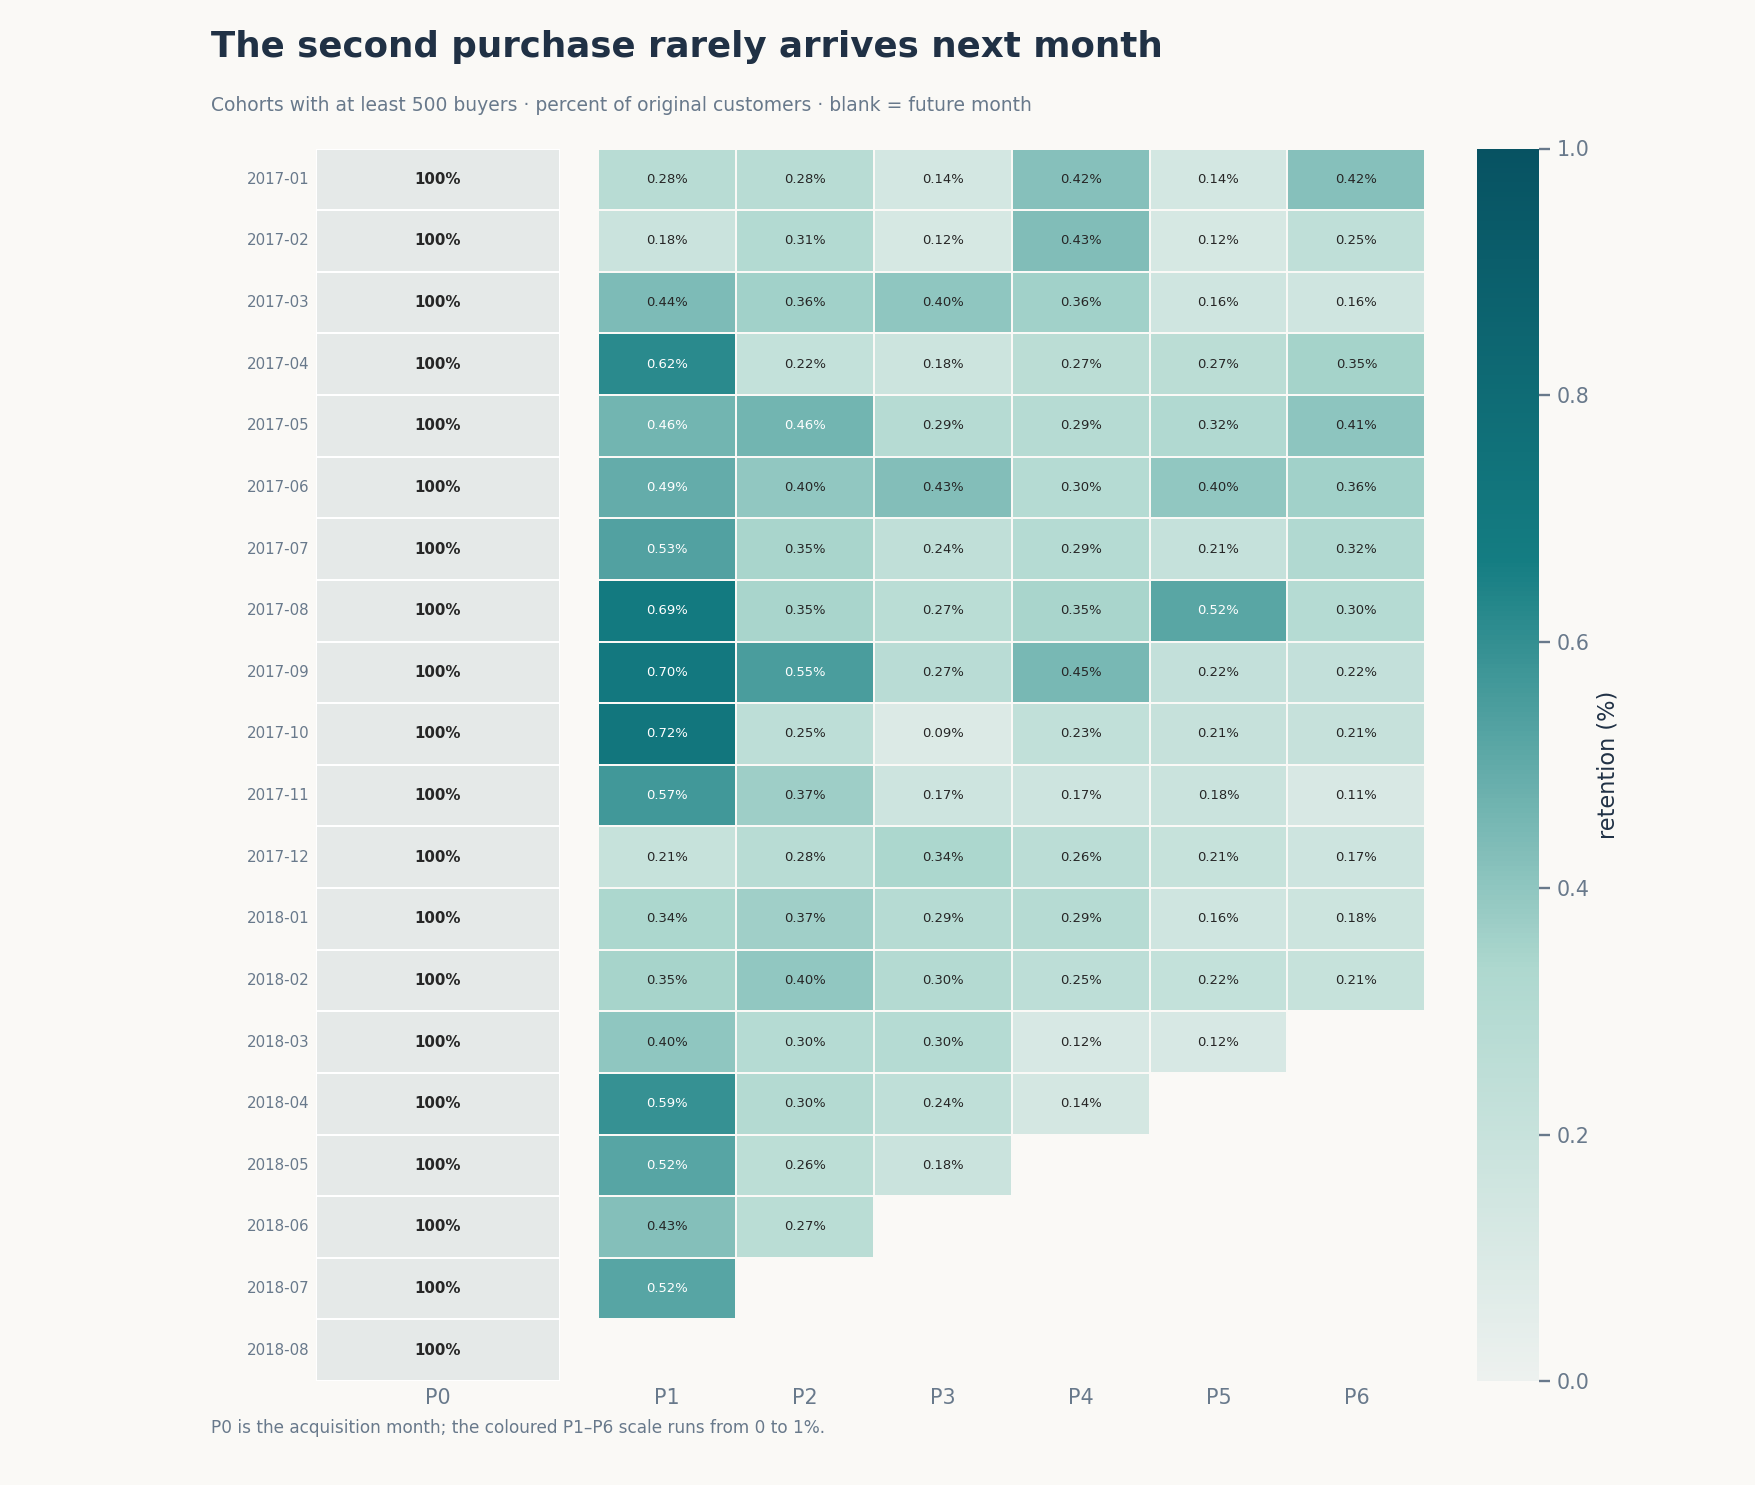

In [14]:
matrix = q7[q7.cohort_size >= 500].set_index('cohort_month')[[f'p{i}' for i in range(1, 7)]].copy()
matrix.index = matrix.index.str[:7]
labels = matrix.map(lambda x: '' if pd.isna(x) else f'{x:.2f}%')
mask = matrix.isna()
cmap = LinearSegmentedColormap.from_list('repeat', ['#edf1ef', '#aed8cf', '#147d82', '#075262'])
fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(1, 2, width_ratios=[1.65, 7], wspace=.06)
ax0 = fig.add_subplot(gs[0]); ax = fig.add_subplot(gs[1])
sns.heatmap(np.ones((len(matrix), 1)), cmap=['#e5e9e8'], cbar=False,
    xticklabels=['P0'], yticklabels=matrix.index, ax=ax0, linewidths=.8,
    annot=np.full((len(matrix), 1), '100%'), fmt='', annot_kws={'size':8,'weight':'bold'})
sns.heatmap(matrix, mask=mask, cmap=cmap, vmin=0, vmax=1.0, cbar_kws={'label':'retention (%)'},
    annot=labels, fmt='', annot_kws={'size':7}, linewidths=.8, linecolor=bg,
    xticklabels=[f'P{i}' for i in range(1,7)], yticklabels=False, ax=ax)
ax0.tick_params(axis='y', labelsize=8, length=0); ax0.tick_params(axis='x', length=0)
ax0.set_yticks(np.arange(len(matrix)) + .5)
ax0.set_yticklabels(matrix.index, rotation=0)
ax0.tick_params(axis='y', labelleft=True)
ax0.set_ylabel('')
ax.tick_params(axis='x', length=0)
ax.set_ylabel('')
fig.suptitle('The second purchase rarely arrives next month', fontsize=19, fontweight='bold', x=.12, ha='left')
fig.text(.12, .925, 'Cohorts with at least 500 buyers · percent of original customers · blank = future month', color=muted)
fig.text(.12, .035, 'P0 is the acquisition month; the coloured P1–P6 scale runs from 0 to 1%.', color=muted, fontsize=9)
fig.subplots_adjust(left=.18, right=.93, top=.90, bottom=.07)
fig.savefig(folder / 'figures' / '01_retention_heatmap.png', dpi=180)
plt.show()


## Visual 2 — average retention curve

The left panel shows the full 100%-to-month-1 fall; the right panel preserves the small differences across later months. The count next to each point is the number of cohorts mature enough to contribute.

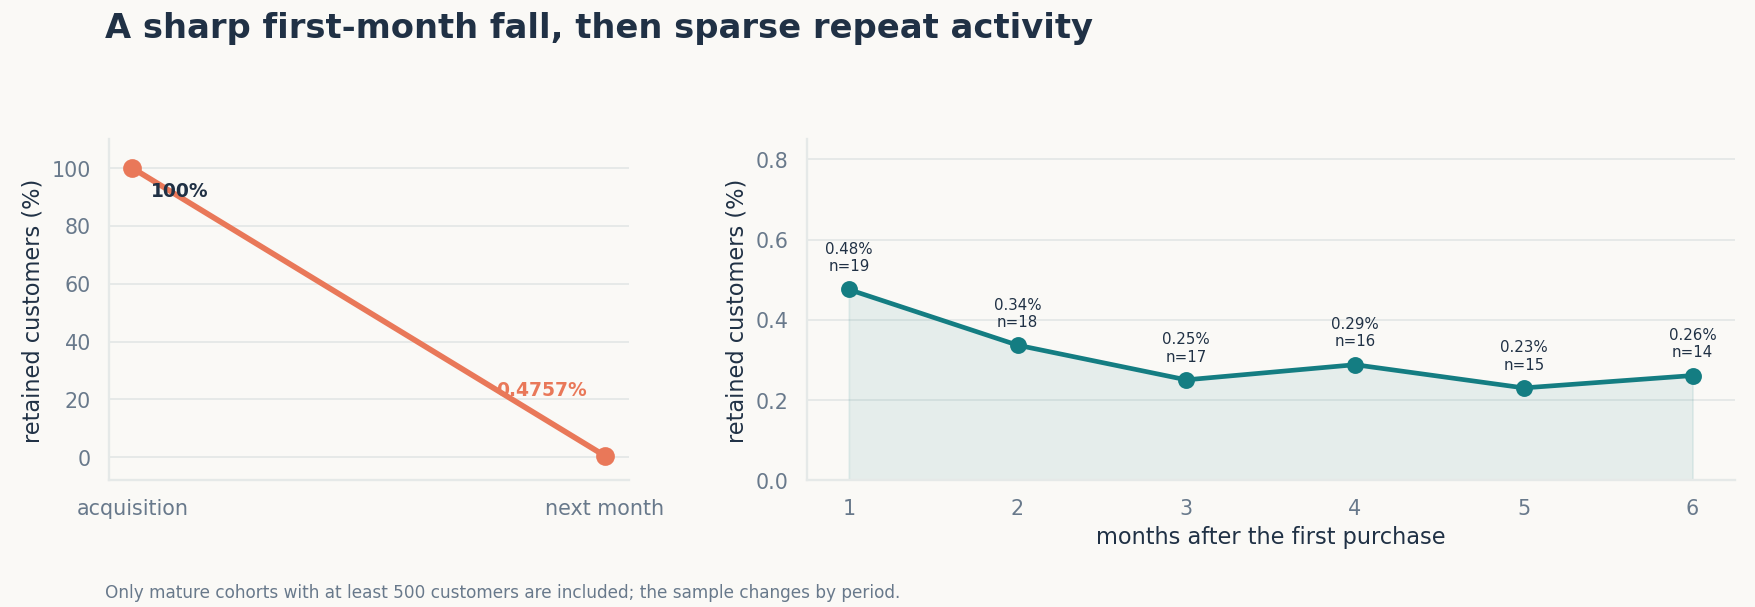

In [15]:
curve = q8.copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={'width_ratios':[1.4, 2.5]})
axes[0].plot(curve.period_number.iloc[:2], curve.average_retention_pct.iloc[:2],
    lw=3, marker='o', markersize=9, color=coral)
axes[0].set(xticks=[0,1], xticklabels=['acquisition','next month'], ylabel='retained customers (%)', ylim=(-8,110))
axes[0].annotate(f"{curve.average_retention_pct.iloc[1]:.4f}%", (1,curve.average_retention_pct.iloc[1]),
    xytext=(-58,32), textcoords='offset points', color=coral, fontweight='bold')
axes[0].annotate('100%', (0,100), xytext=(10,-15), textcoords='offset points', color=ink, fontweight='bold')
later = curve.iloc[1:]
axes[1].plot(later.period_number, later.average_retention_pct, marker='o', markersize=8,
    lw=2.5, color=teal)
axes[1].fill_between(later.period_number, later.average_retention_pct, color=teal, alpha=.09)
axes[1].set(xticks=list(later.period_number), xlabel='months after the first purchase',
    ylim=(0,.85), ylabel='retained customers (%)')
for _, point in later.iterrows():
    axes[1].annotate(f"{point.average_retention_pct:.2f}%\nn={int(point.stable_cohorts)}",
        (point.period_number, point.average_retention_pct), xytext=(0,10),
        textcoords='offset points', ha='center', fontsize=8)
for ax in axes:
    ax.grid(axis='y', color=grid); ax.spines[['top','right']].set_visible(False)
fig.suptitle('A sharp first-month fall, then sparse repeat activity', x=.06, ha='left', fontsize=18, fontweight='bold')
fig.text(.06,.015,'Only mature cohorts with at least 500 customers are included; the sample changes by period.',color=muted,fontsize=9)
fig.tight_layout(rect=(0,.06,1,.89),w_pad=3)
fig.savefig(folder / 'figures' / '02_average_retention_curve.png',dpi=180)
plt.show()


## Visual 3 — cohort size

The bars count newly acquired distinct customers. The small 2016 cohorts remain visible; they are intentionally excluded only from the comparative month-1 curve.

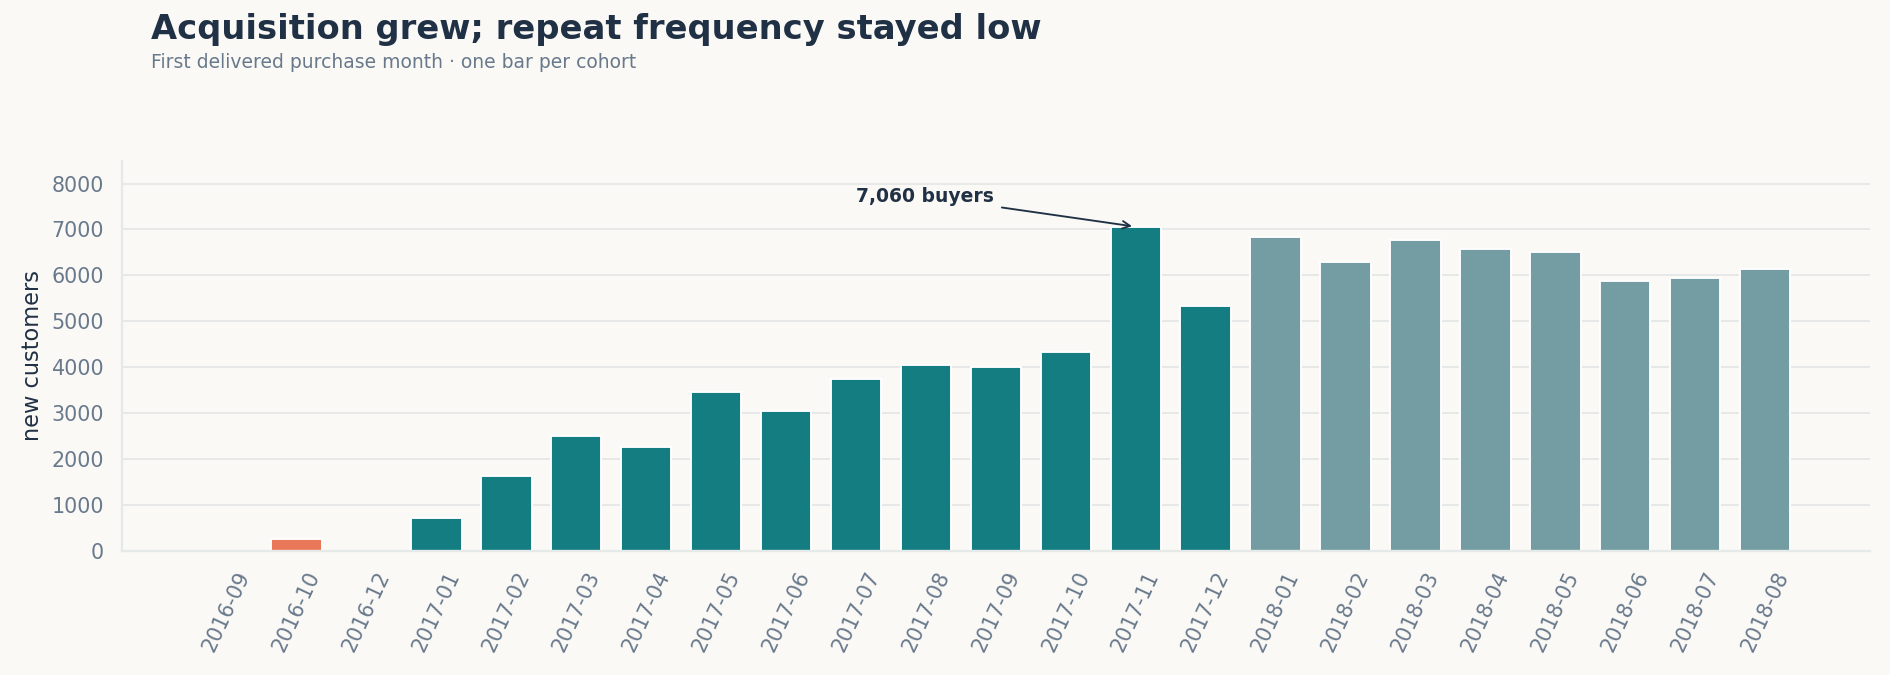

In [16]:
sizes = q6.copy()
sizes['month'] = sizes.cohort_month.str[:7]
colors = [coral if m.startswith('2016') else teal if m.startswith('2017') else '#739ca3' for m in sizes.month]
fig, ax = plt.subplots(figsize=(14,5))
ax.bar(sizes.month,sizes.cohort_size,color=colors,width=.72)
imax = sizes.cohort_size.idxmax()
ax.annotate(f"{sizes.cohort_size.iloc[imax]:,} buyers",xy=(imax,sizes.cohort_size.iloc[imax]),
    xytext=(imax-4,7600),arrowprops={'arrowstyle':'->','color':ink},fontweight='bold')
ax.set(ylabel='new customers',ylim=(0,8500)); ax.tick_params(axis='x',rotation=65)
ax.grid(axis='y',color=grid); ax.set_axisbelow(True); ax.spines[['top','right']].set_visible(False)
fig.suptitle('Acquisition grew; repeat frequency stayed low',x=.08,ha='left',fontsize=18,fontweight='bold')
fig.text(.08,.90,'First delivered purchase month · one bar per cohort',color=muted)
fig.tight_layout(rect=(0,0,1,.87))
fig.savefig(folder / 'figures' / '03_cohort_sizes.png',dpi=180)
plt.show()


## Visual 4 — month-1 ranking

The dot area scales with cohort size, and the labels show the raw number of people who returned. The delivery/review checks in Q9 are used to challenge the interpretation of this ranking.

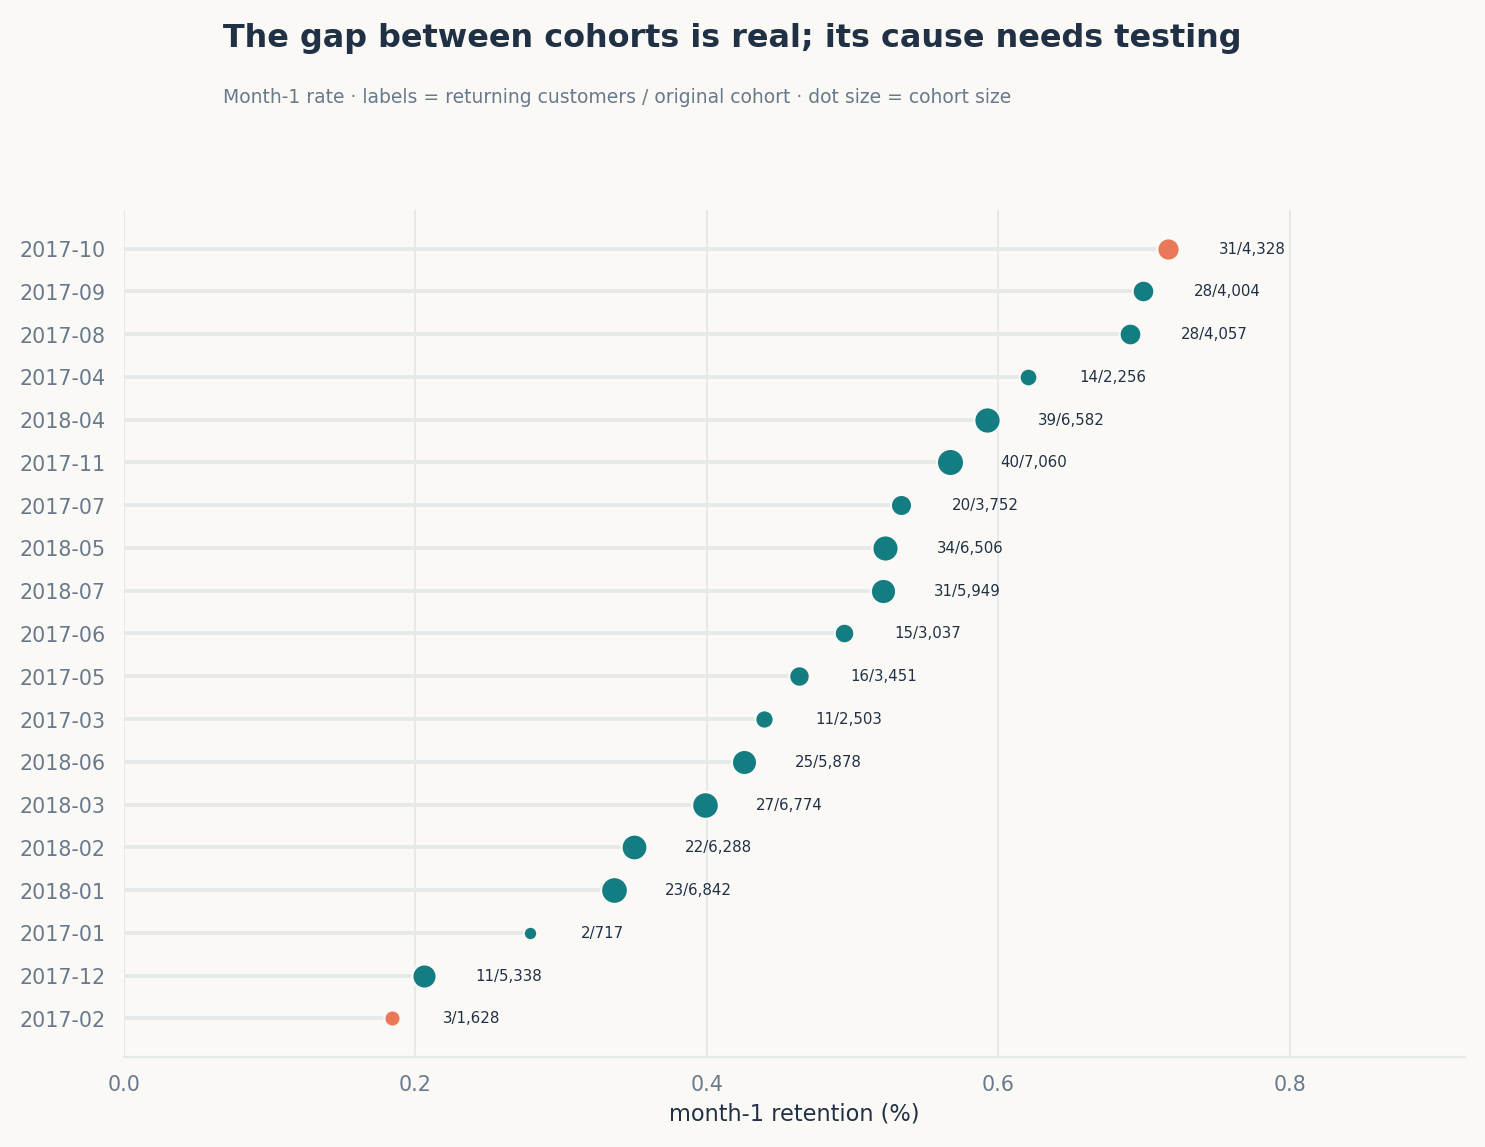

In [17]:
rank = q9.sort_values('month_1_pct').reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11,8.5))
ys = np.arange(len(rank))
for j, r in rank.iterrows():
    col = coral if j in (0,len(rank)-1) else teal
    ax.plot([0,r.month_1_pct],[j,j],color=grid,lw=2,zorder=1)
    ax.scatter(r.month_1_pct,j,s=35+r.cohort_size/40,color=col,edgecolor=bg,lw=1.2,zorder=3)
    ax.text(r.month_1_pct+.035,j,f"{int(r.returning_customers)}/{int(r.cohort_size):,}",va='center',fontsize=8,color=ink)
ax.set(yticks=ys,yticklabels=rank.cohort_month.str[:7],xlabel='month-1 retention (%)',xlim=(0,.92))
ax.grid(axis='x',color=grid); ax.set_axisbelow(True); ax.spines[['top','right','left']].set_visible(False)
fig.suptitle('The gap between cohorts is real; its cause needs testing',x=.15,ha='left',fontsize=17,fontweight='bold')
fig.text(.15,.91,'Month-1 rate · labels = returning customers / original cohort · dot size = cohort size',color=muted)
fig.tight_layout(rect=(0,0,1,.88))
fig.savefig(folder / 'figures' / '04_month1_cohort_ranking.png',dpi=180)
plt.show()


## Visual 5 — incremental revenue bubbles

These values are BRL of product `price` earned in a later month **per original cohort customer**. Bigger circles mean more incremental revenue; grey blanks are months beyond the observed data. The SQL table also includes a running six-month sum.

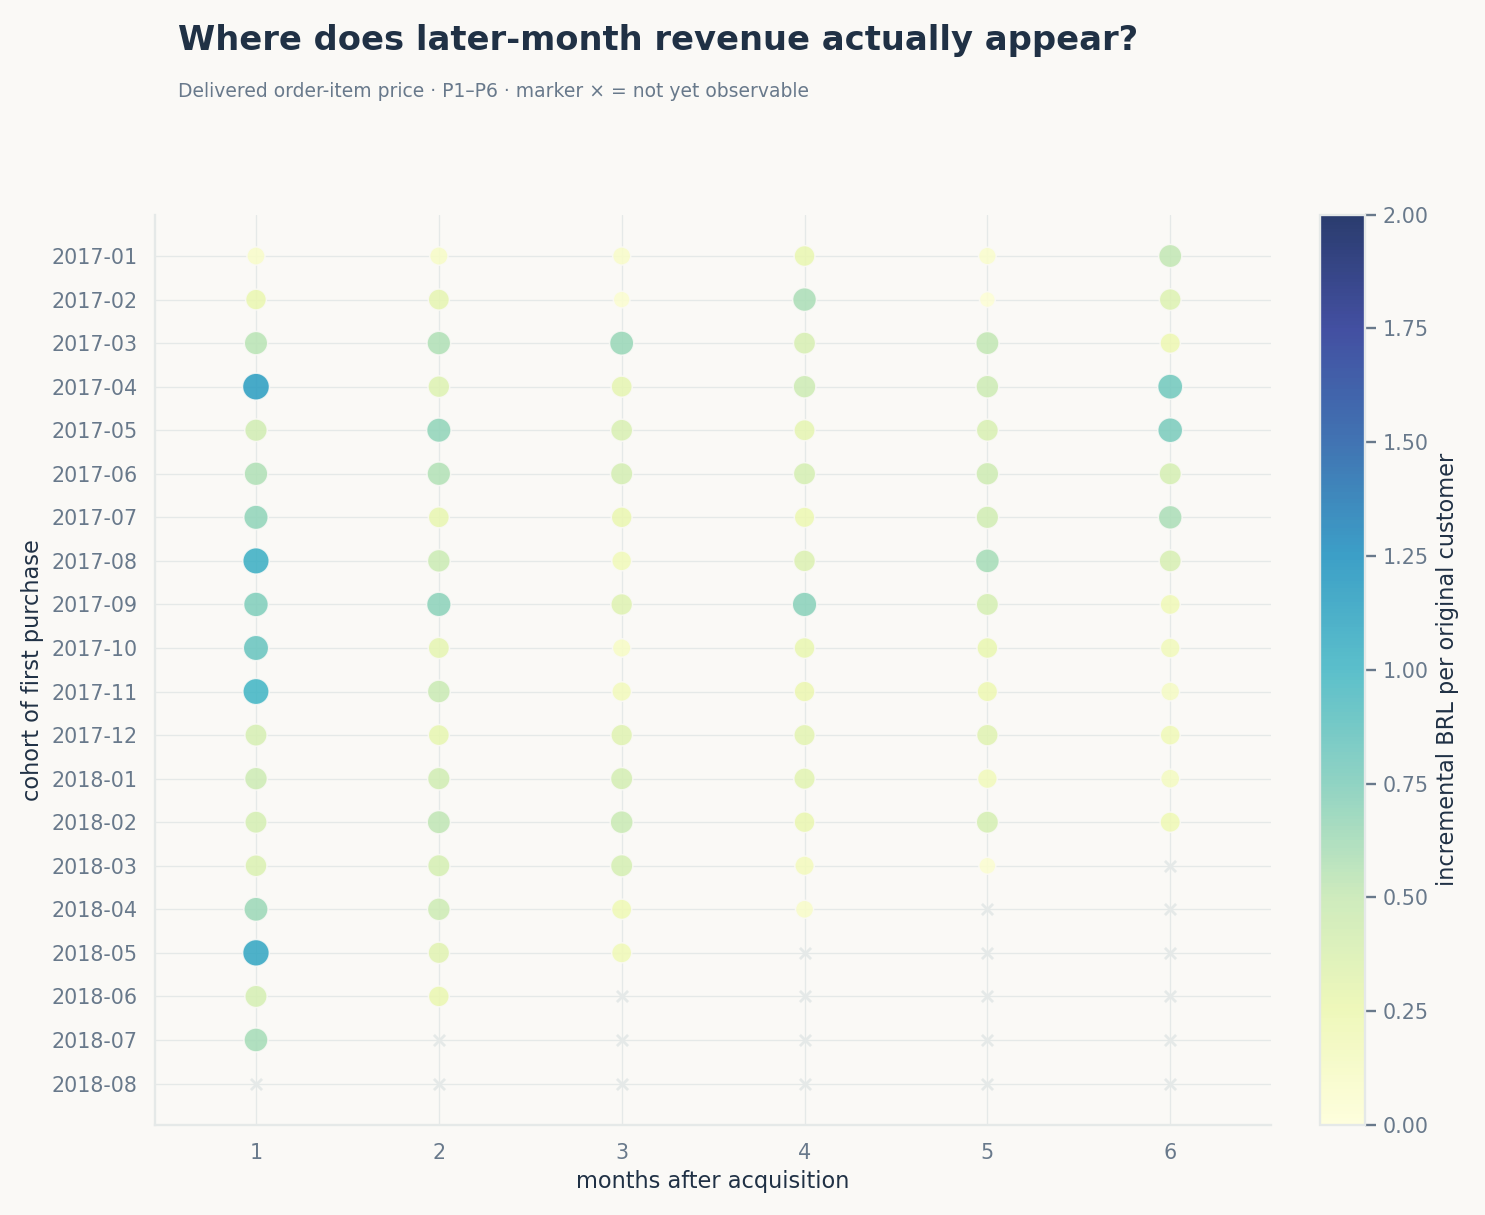

In [18]:
rev = q10[(q10.cohort_month >= '2017-01-01') & (q10.period_number.between(1,6))].copy()
rev['month'] = rev.cohort_month.str[:7]
months = sorted(rev.month.unique()); month_to_y = {m:i for i,m in enumerate(months)}
fig, ax = plt.subplots(figsize=(11,9))
observed = rev.dropna(subset=['revenue_per_original_customer_brl'])
values = observed.revenue_per_original_customer_brl
sc = ax.scatter(observed.period_number,observed.month.map(month_to_y),
    s=45+np.sqrt(values.clip(lower=0))*150,c=values,cmap='YlGnBu',vmin=0,
    vmax=max(2.0,float(values.quantile(.97))),alpha=.86,edgecolor=bg,lw=.8)
for _,r in rev[rev.revenue_brl.isna()].iterrows():
    ax.scatter(r.period_number,month_to_y[r.month],marker='x',color=grid,s=35)
ax.set(xticks=range(1,7),yticks=range(len(months)),yticklabels=months,
    xlabel='months after acquisition',ylabel='cohort of first purchase',xlim=(.45,6.55))
ax.invert_yaxis(); ax.grid(color=grid,lw=.7); ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
fig.colorbar(sc,ax=ax,label='incremental BRL per original customer',fraction=.046,pad=.04)
fig.suptitle('Where does later-month revenue actually appear?',x=.12,ha='left',fontsize=18,fontweight='bold')
fig.text(.12,.92,'Delivered order-item price · P1–P6 · marker × = not yet observable',color=muted)
fig.tight_layout(rect=(0,0,1,.89))
fig.savefig(folder / 'figures' / '05_incremental_revenue_bubbles.png',dpi=180)
plt.show()


## Reading the results

The four evidence-based conclusions and the tested (unsupported) delivery hypothesis are in `note.md`. Month 1 is a calendar-month return measure, so a customer who comes back after two months contributes to P2 even if they did not purchase in P1.